# The best MFAS solution, end-to-end — H35 (under-relaxed sift)

This notebook **runs the project's best solution** and shows **why it works**.

**Best solution = H35** (`experiments/findings.md` #5). On the fly connectome it reaches
**83.91%** feedforward weight — the highest we obtain — recovering **~58%** of the
Rocket↔optimum gap with **no MIP and 0 extra gradient steps**.

**Pipeline** (identical to `src/mfas/experiments/H35.py`):
1. **Greedy-FAS warm start** (H02): `greedy_fas_order(g)` → evenly-spaced positions.
2. **Unchanged Rocket** at the baseline epoch budget → the *pure* Rocket order.
3. **Under-relaxed two-phase exact-gain sift**: `k_full` warm Jacobi sweeps (α=1), then
   under-relaxed sweeps (α=0.7). The frozen oracle only accepts/rejects whole rank vectors
   (best-by-oracle), so the refined order can never regress below pure Rocket.

**What makes H35 the best (the mechanism this notebook visualises).** The previous best,
**H30**, uses a *plain Jacobi* sift: every node jumps FULLY to its exact-optimal gap each
sweep. On large dense connectomes this **does not converge** — it enters a period-2 **limit
cycle** (thousands of nodes leapfrogging each other forever), so best-by-oracle only creeps
up via the lucky phase of the oscillation. **Under-relaxation** (move each node only a
fraction α of the way to its target) is the textbook cure: it damps the cycle, the movers
collapse, and the iterate settles at a strictly higher fixed point. At α=1, H35 is
bit-identical to H30 — so the whole win comes from α<1.

> **Leakage-safe / equal-compute (CLAUDE.md).** The sift adds **0 gradient steps**; every
> move is chosen from input edge weights + current ranks; the frozen oracle only
> accepts/rejects whole rank vectors. The *pure* Rocket score is reported separately from
> the refinement.

> **Where to see the headline.** The limit cycle is a **large-dense-graph** effect, so the
> dramatic mechanism plots and the 83.91% figure appear on **`connectome`**. The notebook
> defaults to **`mouse`** (runs in seconds, proves the pipeline end-to-end); set
> `CONFIG['DATASET'] = 'connectome'` for the real result (~5–8 min).


## 1. Setup — imports, device, CONFIG

All hyperparameters live in `CONFIG` (no magic numbers). We add the repo's `src/` to the
path so the frozen `mfas.*` modules import cleanly regardless of where the kernel started.

Optimization (Rocket) runs on MPS/CUDA if available; the **discrete score and both sifts are
always computed on CPU in NumPy** (MPS float32 index ops can corrupt large-graph scores —
see CLAUDE.md), so results are deterministic given the seed (modulo MPS training jitter,
which only affects the *pure* Rocket order feeding the sift).


# TODO

1) посчитать расстояние и насколько отличаются результаты друг от друга при разных сидах (без жадного старта)
2) стохастик градиент десент (на части нейронов и двигаем часть)
3) пробовать чередовать дискретную часть и градиентную и
4) постараться полностью понять почему ухудшается если начинаем с лучшего решения
5) попробовать инициализацию, в которой мы стартуем с очень близких позиций нейронов
6) SCC из статьи
7) попробовать другую функцию оптимизации (вместо сигмойды брать константу наверху и внизу тангенс который медленнее за

для сравнения со случайным - stochastic block model (сравнивать не с совсем случайным графом) Но и как оптимизацию делать сначала по кластерам а потом кластеры отдельно. 
spectral clustering (лапласем)

In [9]:
import sys, time
from pathlib import Path
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt


def _find_repo_root(start: Path) -> Path:
    # Walk up until we find the frozen oracle; works from notebooks/ or the repo root.
    for p in [start, *start.parents]:
        if (p / 'src' / 'mfas' / 'metrics.py').exists():
            return p
    raise FileNotFoundError(f'Could not locate src/mfas/metrics.py above {start}')


REPO = _find_repo_root(Path.cwd())
sys.path.insert(0, str(REPO / 'src'))

from mfas.io import load_dataset
from mfas.baseline.rocket import RocketConfig, run_rocket
from mfas.experiments.H02 import greedy_fas_order, _init_positions_from_order
from mfas.refine import sift, sift_underrelaxed          # H30 (Jacobi) and H35 (under-relaxed)
from mfas.metrics import score_from_order, pct

GLOBAL_SEED = 42
np.random.seed(GLOBAL_SEED)
torch.manual_seed(GLOBAL_SEED)

if torch.backends.mps.is_available():
    DEVICE = torch.device('mps')
elif torch.cuda.is_available():
    DEVICE = torch.device('cuda')
else:
    DEVICE = torch.device('cpu')

CONFIG = dict(
    # 'mouse' (~seconds) | 'connectome' (~5-8 min) | 'microns' (~minutes; needs the .npz cache)
    DATASET         = 'connectome',
    SEED            = GLOBAL_SEED,
    # Baseline gradient budget per dataset (= the H02/H30/H35 production budget).
    ROCKET_EPOCHS   = {'mouse': 5_000, 'connectome': 20_000, 'microns': 80_000},
    # Max sift sweeps per dataset (production H30/H35 values; matched so H35 vs H30 isolates alpha).
    SIFT_MAX_SWEEPS = {'connectome': 40, 'mouse': 40, 'microns': 12},
    # H35 under-relaxation knobs (production values from src/mfas/experiments/H35.py).
    K_FULL          = 6,      # warm Jacobi sweeps (alpha=1) before switching to under-relaxation
    ALPHA           = 0.7,    # under-relaxation factor (sweet spot from the dr_tmp sizing)
    # Near-optimal reference (data/best_solution) — CONNECTOME ONLY; used to report % of gap closed.
    GAP_REFERENCE_PCT = {'connectome': 84.6147},
    OUTPUT_DIR      = REPO / 'notebooks' / 'outputs',
)
CONFIG['OUTPUT_DIR'].mkdir(parents=True, exist_ok=True)

DATASET   = CONFIG['DATASET']
SEED      = CONFIG['SEED']
MAX_SWEEP = CONFIG['SIFT_MAX_SWEEPS'][DATASET]
print(f'Repo: {REPO}')
print(f'Device: {DEVICE}  |  dataset: {DATASET}  |  seed: {SEED}')
print(f'sift: max_sweeps={MAX_SWEEP}  k_full={CONFIG["K_FULL"]}  alpha={CONFIG["ALPHA"]}')


Repo: /Users/abed359/IdeaProjects/university/deeplearning_thesis/nn_backward_connections
Device: mps  |  dataset: connectome  |  seed: 42
sift: max_sweeps=40  k_full=6  alpha=0.7


## 2. Load a dataset

`mfas.io.load_dataset` resolves the data files relative to the repo and validates basic
facts (node/edge counts, total weight). Start with **`mouse`** for instant iteration; switch
`CONFIG['DATASET']` to `connectome` for the headline **83.91%** and the dramatic limit-cycle
plots (the fly connectome is where the Jacobi cycle appears; mouse converges immediately).


In [10]:
g = load_dataset(DATASET)
TOTAL = g.total_weight
print(g)


GraphData(name='connectome', n_nodes=136,648, n_edges=5,657,719, total_weight=41,912,141, weight_dtype=int64)


## 3. Stage 1+2 — greedy-FAS warm start + (unchanged) Rocket = *pure* Rocket

This is exactly H02: a leakage-safe **Eades–Lin–Smyth / GreedyAbs** greedy-FAS ordering
(graph structure + weights only, never the oracle) mapped to evenly-spaced positions in
`[-1, 1]`, then handed to the **unchanged** `run_rocket` at the baseline epoch budget. The
result is the *pure* Rocket order — reported separately from any refinement (CLAUDE.md). Both
sifts below start from **this same** order, so the comparison isolates the sift dynamics.


In [11]:
epochs = CONFIG['ROCKET_EPOCHS'][DATASET]
cfg = RocketConfig(epochs=epochs)

# Greedy-FAS order alone (context): the discrete heuristic Rocket is warm-started from.
order = greedy_fas_order(g)
greedy_pct = pct(score_from_order(order, g.src, g.tgt, g.weight), TOTAL)

t0 = time.time()
init_positions = _init_positions_from_order(order, DEVICE)
rocket = run_rocket(g, cfg, seed=SEED, device=DEVICE, init_positions=init_positions)
rocket_wall = time.time() - t0

pure_pct = rocket.best_pct

# Integer ranks of the pure-Rocket positions (rank[node] = position on the line);
# this is the shared starting order for both sifts.
rank0 = np.argsort(np.argsort(rocket.best_positions, kind='stable'),
                   kind='stable').astype(np.int64)
init_pct = pct(score_from_order(rank0, g.src, g.tgt, g.weight), TOTAL)
assert abs(init_pct - pure_pct) < 1e-9, 'ranks of the best positions must score == pure Rocket'

print(f'greedy-FAS order alone     : {greedy_pct:8.4f}%')
print(f'pure Rocket (H02 warmstart): {pure_pct:8.4f}%   '
      f'({rocket.best_score:,.0f} / {TOTAL:,.0f})')
print(f'  epochs={rocket.n_epochs_done:,}   wall={rocket_wall:.1f}s   device={DEVICE}')


greedy-FAS order alone     :  68.9134%
pure Rocket (H02 warmstart):  82.9292%   (34,757,421 / 41,912,141)
  epochs=20,000   wall=83.4s   device=mps


## 4. Stage 3a — plain Jacobi sift (H30, the previous best) for comparison

We first run the **previous** best, H30's `mfas.refine.sift`: a plain **Jacobi** iteration
where every node jumps FULLY to its exact feedforward-maximising gap each sweep (α=1). We run
it at the same `max_sweeps` as H35 so the only difference is the under-relaxation.

`sift` returns `(best_rank, best_score, sweep_log)`. Each `sweep_log` row records `sweep`,
`candidate_pct` (the working Jacobi iterate — **oscillates** on dense cyclic cores),
`accepted` (did the oracle keep it as the new best?), `n_movers` (how many nodes still want
to move — the **limit-cycle detector**: it stays high and never reaches 0 on the connectome),
and `wall`.


In [12]:
t0 = time.time()
h30_rank, h30_score, h30_log = sift(g, rank0, max_sweeps=MAX_SWEEP)
h30_wall = time.time() - t0

h30_pct = pct(h30_score, TOTAL)
h30_df = pd.DataFrame(h30_log)
h30_fixed = h30_df['n_movers'].iloc[-1] == 0
print(f'H30 plain-Jacobi sift : {h30_pct:8.4f}%   (+{h30_pct - pure_pct:.4f} pp over pure Rocket)')
print(f'  sweeps run={len(h30_df)}   reached fixed point={h30_fixed}   '
      f'final movers={int(h30_df["n_movers"].iloc[-1]):,}   wall={h30_wall:.1f}s')


H30 plain-Jacobi sift :  83.8069%   (+0.8777 pp over pure Rocket)
  sweeps run=40   reached fixed point=False   final movers=5,225   wall=97.9s


## 5. Stage 3b — under-relaxed two-phase sift (H35, the best solution)

Now the winner: `mfas.refine.sift_underrelaxed`. Same brute-force-verified exact-gain kernel
as H30, but the rebuild moves each mover only a fraction **α = 0.7** toward its target after
**`k_full` = 6** warm full-Jacobi sweeps:

```
key = rank + α · (target − rank)        (α = 1 for the first k_full sweeps, then 0.7)
```

Under-relaxation is the standard fix for a Jacobi period-2 cycle. Watch `n_movers` **collapse**
(the cycle breaks) and `candidate_pct` **converge upward** instead of sawtoothing.


In [13]:
t0 = time.time()
h35_rank, h35_score, h35_log = sift_underrelaxed(
    g, rank0, k_full=CONFIG['K_FULL'], alpha=CONFIG['ALPHA'], max_sweeps=MAX_SWEEP)
h35_wall = time.time() - t0

h35_pct = pct(h35_score, TOTAL)
h35_df = pd.DataFrame(h35_log)
h35_fixed = h35_df['n_movers'].iloc[-1] == 0
print(f'H35 under-relaxed sift : {h35_pct:8.4f}%   (+{h35_pct - pure_pct:.4f} pp over pure Rocket)')
print(f'  sweeps run={len(h35_df)}   reached fixed point={h35_fixed} 
'
      f'final movers={int(h35_df["n_movers"].iloc[-1]):,}   wall={h35_wall:.1f}s')
print(f'  H35 vs H30 : {h35_pct - h30_pct:+.4f} pp   (>=0 by design: best-by-oracle keeps the max)')


H35 under-relaxed sift :  83.9081%   (+0.9788 pp over pure Rocket)
  sweeps run=40   reached fixed point=False   final movers=156   wall=94.2s
  H35 vs H30 : +0.1012 pp   (>=0 by design: best-by-oracle keeps the max)


## 6. The mechanism — limit cycle (H30) vs damped convergence (H35)

Two panels side by side:

- **Left — the score trajectory.** `candidate_pct` is the *working* iterate each sweep;
  `best_pct_after` is best-by-oracle (running max, what the method returns). On the
  **connectome** the H30 (Jacobi) candidate **sawtooths** (period-2 cycle) while the H35
  candidate **climbs and settles** — its best-by-oracle ends strictly higher.
- **Right — the movers count (the limit-cycle detector).** `n_movers` = how many nodes still
  want to move. Plain Jacobi (H30) **stays high forever** (~thousands stuck leapfrogging);
  under-relaxation (H35) **collapses it** toward a few hundred / zero — the cycle is broken.

On **mouse** both converge in a few sweeps (no cycle to break), so the two curves nearly
coincide — that is the honest "non-regressing on small graphs" case. Flip to `connectome` to
see the dramatic separation that yields the 83.91% headline.


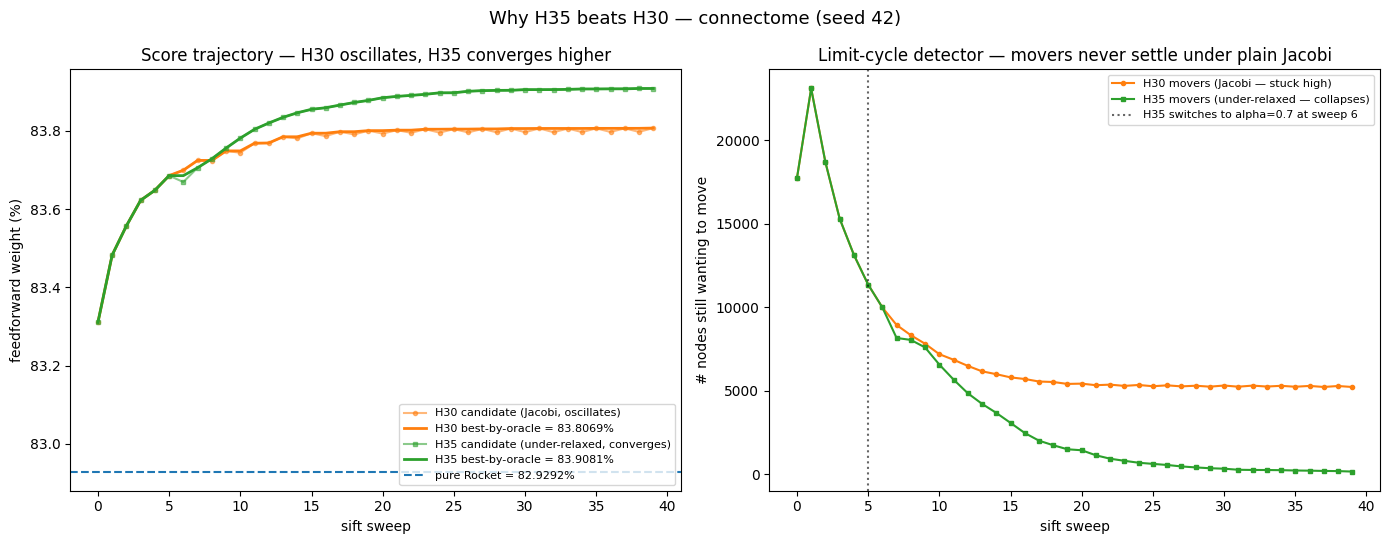

saved /Users/abed359/IdeaProjects/university/deeplearning_thesis/nn_backward_connections/notebooks/outputs/h35_mechanism_connectome_s42.png


In [14]:
def best_by_oracle_curve(df, floor_pct):
    """Running max of candidate_pct, floored by the initial (pure Rocket) order."""
    return np.maximum.accumulate(
        np.concatenate([[floor_pct], df['candidate_pct'].to_numpy()]))[1:]

h30_best = best_by_oracle_curve(h30_df, init_pct)
h35_best = best_by_oracle_curve(h35_df, init_pct)

fig, (axL, axR) = plt.subplots(1, 2, figsize=(14, 5.5))

# ── Left: score trajectory ──
axL.plot(h30_df['sweep'], h30_df['candidate_pct'], 'o-', ms=3, color='tab:orange',
         alpha=0.55, label='H30 candidate (Jacobi, oscillates)')
axL.plot(h30_df['sweep'], h30_best, '-', lw=2, color='tab:orange',
         label=f'H30 best-by-oracle = {h30_pct:.4f}%')
axL.plot(h35_df['sweep'], h35_df['candidate_pct'], 's-', ms=3, color='tab:green',
         alpha=0.55, label='H35 candidate (under-relaxed, converges)')
axL.plot(h35_df['sweep'], h35_best, '-', lw=2, color='tab:green',
         label=f'H35 best-by-oracle = {h35_pct:.4f}%')
axL.axhline(pure_pct, color='tab:blue', ls='--', label=f'pure Rocket = {pure_pct:.4f}%')
axL.set_xlabel('sift sweep')
axL.set_ylabel('feedforward weight (%)')
axL.set_title('Score trajectory — H30 oscillates, H35 converges higher')
axL.legend(loc='lower right', fontsize=8)

# ── Right: movers (limit-cycle detector) ──
axR.plot(h30_df['sweep'], h30_df['n_movers'], 'o-', ms=3, color='tab:orange',
         label='H30 movers (Jacobi — stuck high)')
axR.plot(h35_df['sweep'], h35_df['n_movers'], 's-', ms=3, color='tab:green',
         label='H35 movers (under-relaxed — collapses)')
if CONFIG['K_FULL'] < MAX_SWEEP:
    axR.axvline(CONFIG['K_FULL'] - 1, color='black', ls=':', alpha=0.6,
                label=f'H35 switches to alpha={CONFIG["ALPHA"]} at sweep {CONFIG["K_FULL"]}')
axR.set_xlabel('sift sweep')
axR.set_ylabel('# nodes still wanting to move')
axR.set_title('Limit-cycle detector — movers never settle under plain Jacobi')
axR.legend(loc='upper right', fontsize=8)

fig.suptitle(f'Why H35 beats H30 — {DATASET} (seed {SEED})', fontsize=13)
plt.tight_layout()
out_png = CONFIG['OUTPUT_DIR'] / f'h35_mechanism_{DATASET}_s{SEED}.png'
plt.savefig(out_png, dpi=120, bbox_inches='tight')
plt.show()
print('saved', out_png)


## 7. Headline — Rocket → H30 → H35, and the gap recovered

The staircase of improvements at **equal gradient budget** (the sift adds 0 optimizer steps).
When a near-optimal reference exists (`data/best_solution`, **connectome only** = 84.6147%),
we also report the **% of the Rocket↔optimum gap** each stage closes.


In [15]:
ref_pct = CONFIG['GAP_REFERENCE_PCT'].get(DATASET)   # None unless connectome


def gap_closed(x):
    """% of the Rocket->reference gap closed by score x (None if no reference)."""
    if ref_pct is None or ref_pct <= pure_pct:
        return None
    return 100.0 * (x - pure_pct) / (ref_pct - pure_pct)


rows = [
    dict(stage='greedy-FAS order (pre-Rocket)', pct=round(greedy_pct, 4),
         d_vs_pure_pp=round(greedy_pct - pure_pct, 4), gap_closed_pct=None),
    dict(stage='pure Rocket (H02 warm-start)', pct=round(pure_pct, 4),
         d_vs_pure_pp=0.0, gap_closed_pct=gap_closed(pure_pct)),
    dict(stage='H30 plain-Jacobi sift', pct=round(h30_pct, 4),
         d_vs_pure_pp=round(h30_pct - pure_pct, 4), gap_closed_pct=gap_closed(h30_pct)),
    dict(stage='H35 under-relaxed sift (BEST)', pct=round(h35_pct, 4),
         d_vs_pure_pp=round(h35_pct - pure_pct, 4), gap_closed_pct=gap_closed(h35_pct)),
]
summary = pd.DataFrame(rows)
if ref_pct is not None:
    summary['gap_closed_pct'] = summary['gap_closed_pct'].round(1)

print(f'dataset : {DATASET}  (seed {SEED}, {g.n_nodes:,} nodes, {g.n_edges:,} edges)')
if ref_pct is not None:
    print(f'near-optimal reference (data/best_solution) : {ref_pct:.4f}%   '
          f'(Rocket<->optimum gap = {ref_pct - pure_pct:.4f} pp)')
else:
    print('no near-optimal reference for this dataset (gap_closed_pct = n/a)')
print(f'wall-clock : Rocket {rocket_wall:.1f}s + H35 sift {h35_wall:.1f}s   '
      f'(sift adds 0 gradient steps)')
summary


dataset : connectome  (seed 42, 136,648 nodes, 5,657,719 edges)
near-optimal reference (data/best_solution) : 84.6147%   (Rocket<->optimum gap = 1.6855 pp)
wall-clock : Rocket 83.4s + H35 sift 94.2s   (sift adds 0 gradient steps)


,stage,pct,d_vs_pure_pp,gap_closed_pct
0,greedy-FAS order (pre-Rocket),68.9134,-14.0158,NaN
1,pure Rocket (H02 warm-start),82.9292,0.0000,0.0
2,H30 plain-Jacobi sift,83.8069,0.8777,52.1
3,H35 under-relaxed sift (BEST),83.9081,0.9788,58.1


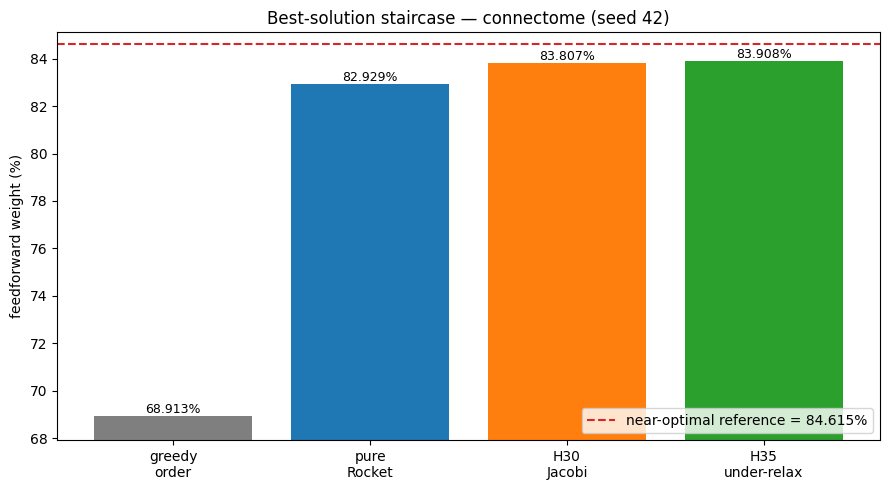

saved /Users/abed359/IdeaProjects/university/deeplearning_thesis/nn_backward_connections/notebooks/outputs/h35_staircase_connectome_s42.png


In [16]:
# Bar chart of the staircase (with the reference gap line when available).
fig, ax = plt.subplots(figsize=(9, 5))
labels = ['greedy\norder', 'pure\nRocket', 'H30\nJacobi', 'H35\nunder-relax']
vals = [greedy_pct, pure_pct, h30_pct, h35_pct]
colors = ['tab:gray', 'tab:blue', 'tab:orange', 'tab:green']
bars = ax.bar(labels, vals, color=colors)
for b, v in zip(bars, vals):
    ax.text(b.get_x() + b.get_width() / 2, v, f'{v:.3f}%', ha='center', va='bottom', fontsize=9)
if ref_pct is not None:
    ax.axhline(ref_pct, color='tab:red', ls='--',
               label=f'near-optimal reference = {ref_pct:.3f}%')
    ax.legend(loc='lower right')
lo = min(greedy_pct, pure_pct) - 1.0
hi = (ref_pct if ref_pct is not None else max(vals)) + 0.5
ax.set_ylim(lo, hi)
ax.set_ylabel('feedforward weight (%)')
ax.set_title(f'Best-solution staircase — {DATASET} (seed {SEED})')
plt.tight_layout()
out_png2 = CONFIG['OUTPUT_DIR'] / f'h35_staircase_{DATASET}_s{SEED}.png'
plt.savefig(out_png2, dpi=120, bbox_inches='tight')
plt.show()
print('saved', out_png2)


## Notes & honest caveats

- **This is a demonstration notebook, not a logged experiment.** The confirmed thesis
  numbers come from the unchanged `eval/run_variant.py` harness on **both** primary datasets,
  **≥3 seeds**, with mean ± std and a 95% CI lower bound (`experiments/findings.md` #5). The
  single-seed numbers here reproduce the pipeline; they are not themselves the confirmed win.
- **Headline is on `connectome`.** H35's confirmed result is **83.91% ± 0.006 (3 seeds)** on
  the fly connectome, **+0.098 pp over H30** (CI lower bound +0.076) — the primary large graph
  where the Rocket↔optimum gap lives. Set `CONFIG['DATASET'] = 'connectome'` and re-run from
  cell 2 to reproduce it (and to see the limit cycle clearly).
- **microns caveat (honest).** On MICrONS the under-relaxation needs more than the 12 sweeps
  budgeted there, so H35 lands ~0.002 pp *below* H30 on microns — H35 is a confirmed
  *connectome* win, not a clean 3-dataset general win like H30. Both still beat pure Rocket.
- **α = 1 ⇔ H30.** `sift_underrelaxed` at `alpha=1.0` is bit-identical to `sift` (asserted in
  `tests/test_refine_underrelax.py`), so the entire H35 gain is the `alpha < 1` dynamics.
- **Equal compute.** The sift adds **0 gradient steps**; the only extra cost of H35 vs pure
  Rocket is wall-clock (~40 sweeps × per-sweep pass over the edges). The equal-gradient-budget
  comparison to Rocket is therefore honest.
- **Frozen oracle.** All scores come from `mfas.metrics` (int64/float64) — the same scorer the
  harness uses. Do not re-implement scoring here.
